    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None

SVM Kernel: linear
Accuracy: 0.86
Confusion Matrix:
 [[61  2]
 [12 25]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.97      0.90        63
 

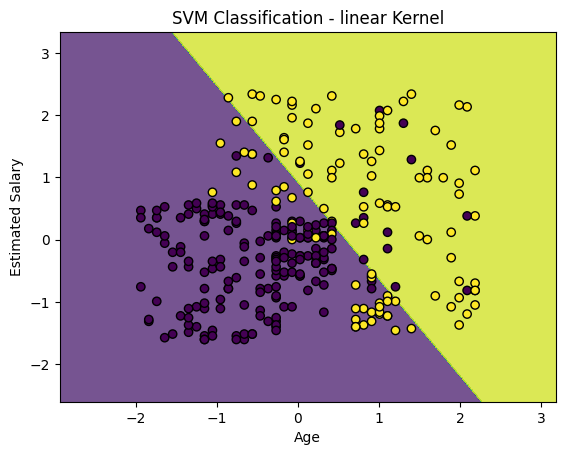


SVM Kernel: poly
Accuracy: 0.85
Confusion Matrix:
 [[63  0]
 [15 22]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.89        63
           1       1.00      0.59      0.75        37

    accuracy                           0.85       100
   macro avg       0.90      0.80      0.82       100
weighted avg       0.88      0.85      0.84       100



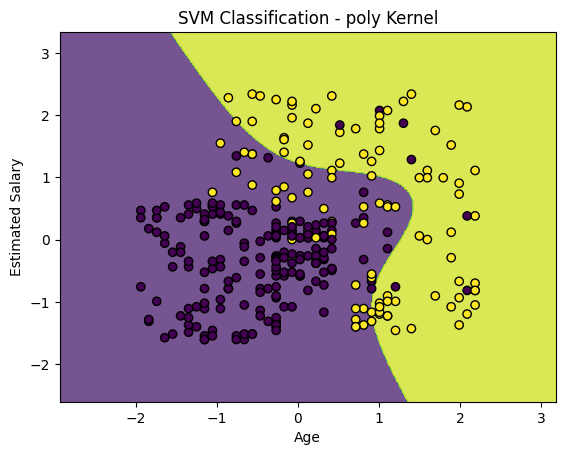


SVM Kernel: rbf
Accuracy: 0.93
Confusion Matrix:
 [[57  6]
 [ 1 36]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.90      0.94        63
           1       0.86      0.97      0.91        37

    accuracy                           0.93       100
   macro avg       0.92      0.94      0.93       100
weighted avg       0.94      0.93      0.93       100



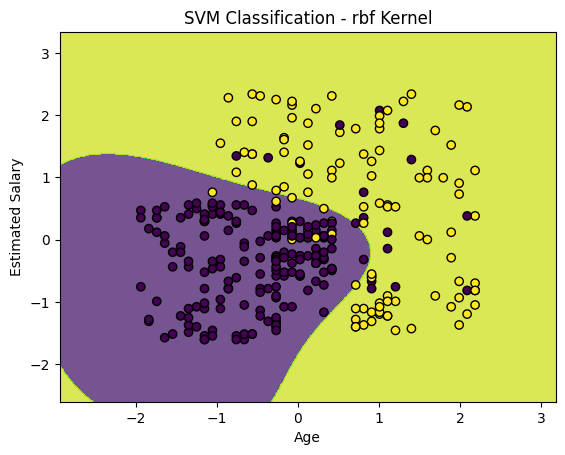

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("/content/Social_Network_Ads.csv")

print(df.head())
print(df.info())

# Select features and target
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

kernels = ["linear", "poly", "rbf"]

for kernel in kernels:
    print("\n==============================")
    print(f"SVM Kernel: {kernel}")

    model = SVC(kernel=kernel, C=1.0, gamma="scale")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Visualize decision boundary
    X_set, y_set = X_train, y_train.values

    x1, x2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
        np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
    )

    plt.contourf(
        x1, x2,
        model.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
        alpha=0.75
    )

    plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, edgecolors="k")
    plt.title(f"SVM Classification - {kernel} Kernel")
    plt.xlabel("Age")
    plt.ylabel("Estimated Salary")
    plt.show()